In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_moons

In [2]:
def get_moons(batch_size=256):
    X, _ = make_moons(n_samples=3000, noise=0.05)

    X = torch.FloatTensor(X)

    dataset = TensorDataset(X)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )

In [3]:
def vae_loss(recon_x, x, mu, logvar):

    recon_loss = nn.functional.mse_loss(
        recon_x,
        x,
        reduction='sum'
    )

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    beta = 0.1

    return recon_loss + beta * kl_loss, recon_loss, kl_loss

In [4]:
def train_vae(model, train_loader, epochs=200, lr=1e-3):

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    losses = []

    for epoch in range(epochs):

        total_loss = 0
        total_recon = 0
        total_kl = 0

        for batch in train_loader:

            x = batch[0]

            recon_x, mu, logvar = model(x)

            loss, recon_loss, kl_loss = vae_loss(
                recon_x,
                x,
                mu,
                logvar
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()

        losses.append(total_loss)

        if epoch % 20 == 0:
            print(
                f"Epoch {epoch:3d} | "
                f"Loss: {total_loss:.2f} | "
                f"Recon: {total_recon:.2f} | "
                f"KL: {total_kl:.2f}"
            )

    return model, losses

In [5]:
class LinearVAE(nn.Module):

    def __init__(self, input_dim=2, latent_dim=2):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim * 2)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def encode(self, x):

        h = self.encoder(x)

        mu, logvar = h.chunk(2, dim=-1)

        return mu, logvar

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)

        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z):

        return self.decoder(z)

    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)

        recon = self.decode(z)

        return recon, mu, logvar

In [6]:
train_loader = get_moons()

model = LinearVAE(
    input_dim=2,
    latent_dim=2
)

model, losses = train_vae(
    model,
    train_loader
)

Epoch   0 | Loss: 4032.54 | Recon: 4016.38 | KL: 161.60
Epoch  20 | Loss: 1178.50 | Recon: 727.83 | KL: 4506.72
Epoch  40 | Loss: 917.64 | Recon: 323.69 | KL: 5939.50
Epoch  60 | Loss: 890.36 | Recon: 296.96 | KL: 5934.05
Epoch  80 | Loss: 866.93 | Recon: 279.86 | KL: 5870.75
Epoch 100 | Loss: 857.97 | Recon: 270.53 | KL: 5874.35
Epoch 120 | Loss: 857.37 | Recon: 278.30 | KL: 5790.69
Epoch 140 | Loss: 840.57 | Recon: 260.27 | KL: 5803.03
Epoch 160 | Loss: 840.30 | Recon: 257.78 | KL: 5825.10
Epoch 180 | Loss: 839.41 | Recon: 253.92 | KL: 5854.84


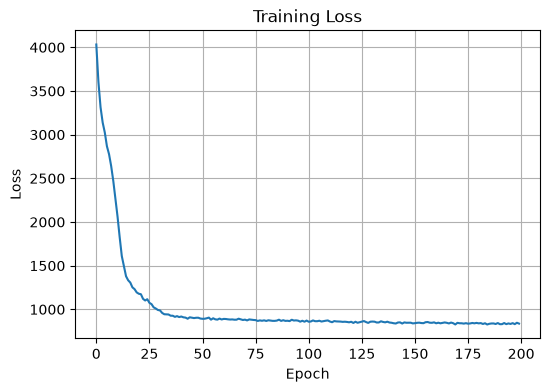

In [7]:
plt.figure(figsize=(6,4))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid(True)

plt.show()

In [8]:
def plot_reconstructions(model, data, n=200):

    with torch.no_grad():

        recon, _, _ = model(data[:n])

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)

    plt.scatter(
        data[:n,0],
        data[:n,1],
        alpha=0.6
    )

    plt.title("Original Data")

    plt.subplot(1,2,2)

    plt.scatter(
        recon[:,0],
        recon[:,1],
        alpha=0.6
    )

    plt.title("Reconstructed Data")

    plt.show()

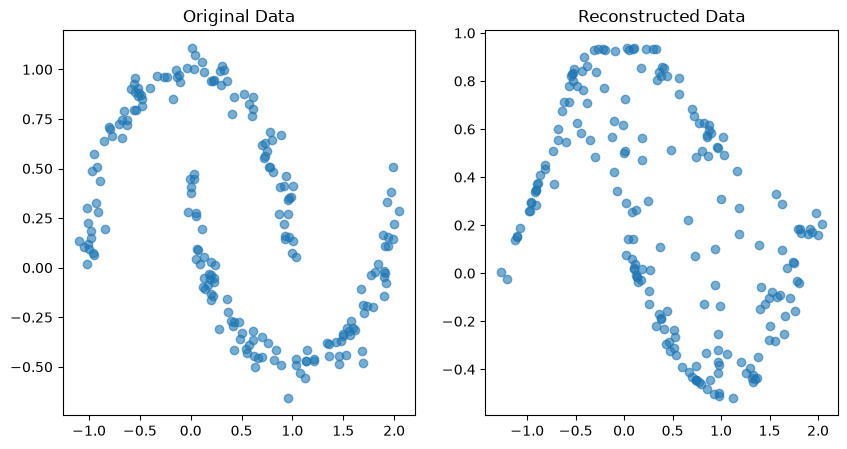

In [9]:
all_data = next(iter(train_loader))[0]

plot_reconstructions(
    model,
    all_data
)

In [10]:
def plot_latent_space(model, data):

    with torch.no_grad():

        mu, logvar = model.encode(data)

    plt.figure(figsize=(6,6))

    plt.scatter(
        mu[:,0],
        mu[:,1],
        alpha=0.5,
        s=10
    )

    plt.xlabel("Latent dim 1")
    plt.ylabel("Latent dim 2")

    plt.title("Latent Space")

    plt.grid(True, alpha=0.3)

    plt.show()

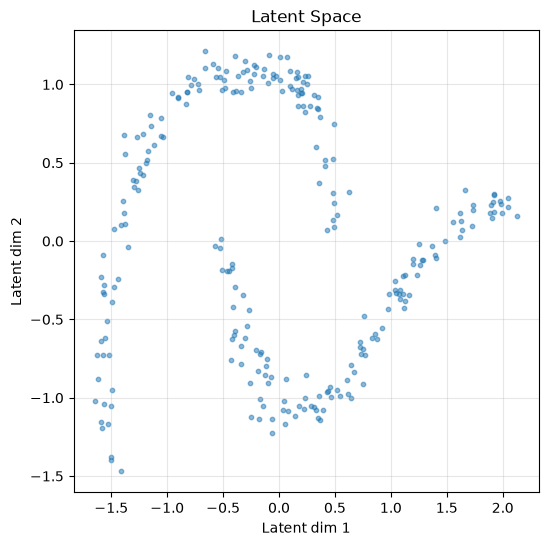

In [11]:
plot_latent_space(
    model,
    all_data
)

In [12]:
def plot_generated(model, n=1000):

    with torch.no_grad():

        z = torch.randn(n, 2)

        samples = model.decode(z)

    plt.figure(figsize=(6,6))

    plt.scatter(
        samples[:,0],
        samples[:,1],
        alpha=0.5,
        s=5
    )

    plt.title("Generated Samples")

    plt.grid(True, alpha=0.3)

    plt.show()

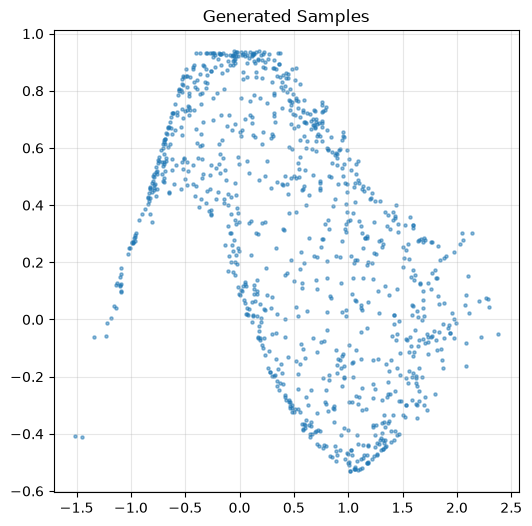

In [13]:
plot_generated(model)